# Phase Classification — CatBoost
Mirrors `phase_classification.ipynb` (XGBoost) exactly, replacing XGBoost with CatBoost.
Same experiments, same cross-fold evaluation, same visualisations.

In [1]:
import json
import numpy as np
import h5py
from catboost import CatBoostClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [2]:
# ── Shared config ─────────────────────────────────────────────────────────────
SPLITS_PATH = "/code/jjiang23/pathml/aim2_balanceV2/data/splits.json"
PHASE_NAMES = ["Phase1", "Phase2", "Phase3", "Phase4"]

LABEL_MAP = {
    b"Phase1":   0,
    b"Phase2":   1,
    b"Phase3":   2,
    b"Phase4":   3,
    b"nonphase": 4,   # excluded
}

CATBOOST_PARAMS = dict(
    loss_function     = "MultiClass",
    iterations        = 400,
    depth             = 6,
    learning_rate     = 0.1,
    # subsample         = 0.8,
    random_seed       = 42,
    thread_count      = -1,
    verbose           = 0,
)

EXPERIMENTS = [
    {
        "name":          "MPW Full (33J)",
        "h5_key":        "world_mp_cropped_iou",
        "joint_indices": None,
    },
    {
        "name":          "MPW Bottom Half (10J)",
        "h5_key":        "world_mp_cropped_iou",
        "joint_indices": list(range(23, 33)),
    },
    {
        "name":          "MPW Top Half (12J)",
        "h5_key":        "world_mp_cropped_iou",
        "joint_indices": list(range(11, 23)),   # shoulders → wrists
    },
    {
        "name":          "MotionBert Full (17J)",
        "h5_key":        "motionBert_cropped_iou",
        "joint_indices": None,
    },
    {
        "name":          "MotionBert Bottom Half (7J)",
        "h5_key":        "motionBert_cropped_iou",
        "joint_indices": list(range(0, 7)),
    },
    {
        "name":          "MotionBert Top Half (10J)",
        "h5_key":        "motionBert_cropped_iou",
        "joint_indices": list(range(7, 17)),
    },
]

with open(SPLITS_PATH) as f:
    splits = json.load(f)

print(f"Folds: {list(splits.keys())}")
print(f"Experiments: {[e['name'] for e in EXPERIMENTS]}")

Folds: ['fold_0', 'fold_1', 'fold_2', 'fold_3', 'fold_4']
Experiments: ['MPW Full (33J)', 'MPW Bottom Half (10J)', 'MPW Top Half (12J)', 'MotionBert Full (17J)', 'MotionBert Bottom Half (7J)', 'MotionBert Top Half (10J)']


In [3]:
# ── Data loaders ──────────────────────────────────────────────────────────────

def load_phase_frames(h5_paths, h5_key, joint_indices=None):
    Xs, ys = [], []
    for path in h5_paths:
        try:
            with h5py.File(path, 'r') as f:
                if h5_key not in f:
                    continue
                raw = f[h5_key][:]
                kp  = (raw[:, 0, :, :3] if raw.ndim == 4 else raw[:, :, :3]).astype(np.float32)
                raw_labels = f['camera_poses_labels'][:]
        except Exception as e:
            print(f"  Skipping {path}: {e}")
            continue
        labels = np.array([LABEL_MAP[lbl] for lbl in raw_labels], dtype=np.int32)
        kp     = np.nan_to_num(kp)
        if joint_indices is not None:
            kp = kp[:, joint_indices, :]
        mask = labels < 4
        if mask.sum() == 0:
            continue
        T, J, D = kp[mask].shape
        Xs.append(kp[mask].reshape(T, J * D))
        ys.append(labels[mask])
    if not Xs:
        return np.empty((0, 0), dtype=np.float32), np.empty((0,), dtype=np.int32)
    return np.concatenate(Xs), np.concatenate(ys)


def load_phase_frames_with_segments(h5_paths, h5_key, joint_indices=None):
    Xs, y_frames, seg_ids_all, seg_true = [], [], [], []
    seg_counter = 0
    for path in h5_paths:
        try:
            with h5py.File(path, 'r') as f:
                if h5_key not in f:
                    continue
                raw = f[h5_key][:]
                kp  = (raw[:, 0, :, :3] if raw.ndim == 4 else raw[:, :, :3]).astype(np.float32)
                raw_labels = f['camera_poses_labels'][:]
        except Exception:
            continue
        labels = np.array([LABEL_MAP[lbl] for lbl in raw_labels], dtype=np.int32)
        kp     = np.nan_to_num(kp)
        if joint_indices is not None:
            kp = kp[:, joint_indices, :]
        mask = labels < 4
        if mask.sum() == 0:
            continue
        kp_ph, lbl_ph = kp[mask], labels[mask]
        T, J, D = kp_ph.shape
        changes    = np.where(np.diff(lbl_ph) != 0)[0] + 1
        boundaries = np.concatenate([[0], changes, [T]])
        seg_ids_video = np.empty(T, dtype=np.int64)
        for start, end in zip(boundaries[:-1], boundaries[1:]):
            seg_ids_video[start:end] = seg_counter
            seg_true.append(lbl_ph[start])
            seg_counter += 1
        Xs.append(kp_ph.reshape(T, J * D))
        y_frames.append(lbl_ph)
        seg_ids_all.append(seg_ids_video)
    if not Xs:
        return (np.empty((0, 0), dtype=np.float32), np.empty((0,), dtype=np.int32),
                np.empty((0,), dtype=np.int64),      np.empty((0,), dtype=np.int32))
    return (np.concatenate(Xs), np.concatenate(y_frames),
            np.concatenate(seg_ids_all), np.array(seg_true, dtype=np.int32))


def majority_vote(y_pred, seg_ids, seg_true):
    unique_segs = np.unique(seg_ids)
    y_pred_seg  = np.array([np.bincount(y_pred[seg_ids == s]).argmax() for s in unique_segs])
    y_true_seg  = np.array([seg_true[i] for i, _ in enumerate(unique_segs)])
    seg_f1 = f1_score(y_true_seg, y_pred_seg, average='macro', zero_division=0)
    return y_pred_seg, y_true_seg, seg_f1

In [4]:
# ── Run all experiments × all folds ──────────────────────────────────────────
all_results = {}

for exp in EXPERIMENTS:
    exp_name = exp['name']
    print(f"\n{'#'*70}")
    print(f"  EXPERIMENT: {exp_name}")
    print(f"{'#'*70}")
    fold_results = []

    for fold_name, fold_data in splits.items():
        print(f"\n  {'='*56}")
        print(f"  {fold_name}")
        print(f"  {'='*56}")

        X_train, y_train = load_phase_frames(
            fold_data['train'], exp['h5_key'], exp['joint_indices'])
        X_val, y_val, seg_ids_val, seg_true_val = load_phase_frames_with_segments(
            fold_data['val'], exp['h5_key'], exp['joint_indices'])

        n_segs = len(np.unique(seg_ids_val)) if len(seg_ids_val) else 0
        print(f"  train: {X_train.shape[0]:,} frames  "
              f"val: {X_val.shape[0]:,} frames ({n_segs} segments)  "
              f"features: {X_train.shape[1] if len(X_train) else 0}")

        if X_train.shape[0] == 0 or X_val.shape[0] == 0:
            print("  Skipping — empty split")
            continue

        sample_weights = compute_sample_weight('balanced', y_train)

        clf = CatBoostClassifier(**CATBOOST_PARAMS)
        clf.fit(
            X_train, y_train,
            sample_weight=sample_weights,
            eval_set=(X_val, y_val),
            early_stopping_rounds=20,
        )

        y_pred_frame = clf.predict(X_val).flatten().astype(np.int32)
        frame_f1     = f1_score(y_val, y_pred_frame, average='macro', zero_division=0)
        y_pred_seg, y_true_seg, seg_f1 = majority_vote(
            y_pred_frame, seg_ids_val, seg_true_val)

        print(f"  Frame macro-F1:   {frame_f1:.4f}")
        print(f"  Segment macro-F1: {seg_f1:.4f}  ({n_segs} segments)")
        print(classification_report(y_true_seg, y_pred_seg,
                                    target_names=PHASE_NAMES, digits=3))

        fold_results.append({
            "fold":       fold_name,
            "frame_f1":   frame_f1,
            "seg_f1":     seg_f1,
            "y_val":      y_val,
            "y_pred":     y_pred_frame,
            "cm_frame":   confusion_matrix(y_val,      y_pred_frame),
            "y_true_seg": y_true_seg,
            "y_pred_seg": y_pred_seg,
            "cm_seg":     confusion_matrix(y_true_seg, y_pred_seg),
        })

    all_results[exp_name] = fold_results


######################################################################
  EXPERIMENT: MPW Full (33J)
######################################################################

  fold_0


  train: 84,773 frames  val: 19,972 frames (73 segments)  features: 99


  Frame macro-F1:   0.7192
  Segment macro-F1: 0.7121  (73 segments)
              precision    recall  f1-score   support

      Phase1      0.680     0.850     0.756        20
      Phase2      0.733     0.550     0.629        20
      Phase3      0.652     0.789     0.714        19
      Phase4      0.900     0.643     0.750        14

    accuracy                          0.712        73
   macro avg      0.741     0.708     0.712        73
weighted avg      0.730     0.712     0.709        73


  fold_1


  train: 83,325 frames  val: 21,420 frames (77 segments)  features: 99


  Frame macro-F1:   0.7242
  Segment macro-F1: 0.7163  (77 segments)
              precision    recall  f1-score   support

      Phase1      0.680     0.810     0.739        21
      Phase2      0.625     0.500     0.556        20
      Phase3      0.750     0.714     0.732        21
      Phase4      0.812     0.867     0.839        15

    accuracy                          0.714        77
   macro avg      0.717     0.723     0.716        77
weighted avg      0.711     0.714     0.709        77


  fold_2


...

  Frame macro-F1:   0.3806
  Segment macro-F1: 0.3609  (77 segments)
              precision    recall  f1-score   support

      Phase1      0.320     0.381     0.348        21
      Phase2      0.417     0.238     0.303        21
      Phase3      0.400     0.300     0.343        20
      Phase4      0.360     0.600     0.450        15

    accuracy                          0.364        77
   macro avg      0.374     0.380     0.361        77
weighted avg      0.375     0.364     0.354        77


  fold_3


  train: 84,375 frames  val: 20,370 frames (74 segments)  features: 30


  Frame macro-F1:   0.3676
  Segment macro-F1: 0.3507  (74 segments)
              precision    recall  f1-score   support

      Phase1      0.353     0.300     0.324        20
      Phase2      0.385     0.250     0.303        20
      Phase3      0.320     0.421     0.364        19
      Phase4      0.368     0.467     0.412        15

    accuracy                          0.351        74
   macro avg      0.356     0.359     0.351        74
weighted avg      0.356     0.351     0.346        74


  fold_4


  train: 84,124 frames  val: 20,621 frames (75 segments)  features: 30


  Frame macro-F1:   0.2886
  Segment macro-F1: 0.2672  (75 segments)
              precision    recall  f1-score   support

      Phase1      0.316     0.286     0.300        21
      Phase2      0.200     0.200     0.200        20
      Phase3      0.286     0.200     0.235        20
      Phase4      0.273     0.429     0.333        14

    accuracy                          0.267        75
   macro avg      0.269     0.279     0.267        75
weighted avg      0.269     0.267     0.262        75



                             Frame F1 Mean  Frame F1 Std  Segment F1 Mean  Segment F1 Std  N Folds
Experiment                                                                                        
MPW Full (33J)                      0.7163        0.0207           0.7236          0.0397        5
MPW Bottom Half (10J)               0.7307        0.0333           0.7263          0.0461        5
MPW Top Half (12J)                  0.2956        0.0428           0.2957          0.0704        5
MotionBert Full (17J)               0.6812        0.0422           0.6756          0.0400        5
MotionBert Bottom Half (7J)         0.6824        0.0457           0.6673          0.0372        5
MotionBert Top Half (10J)           0.3385        0.0387           0.3277          0.0377        5


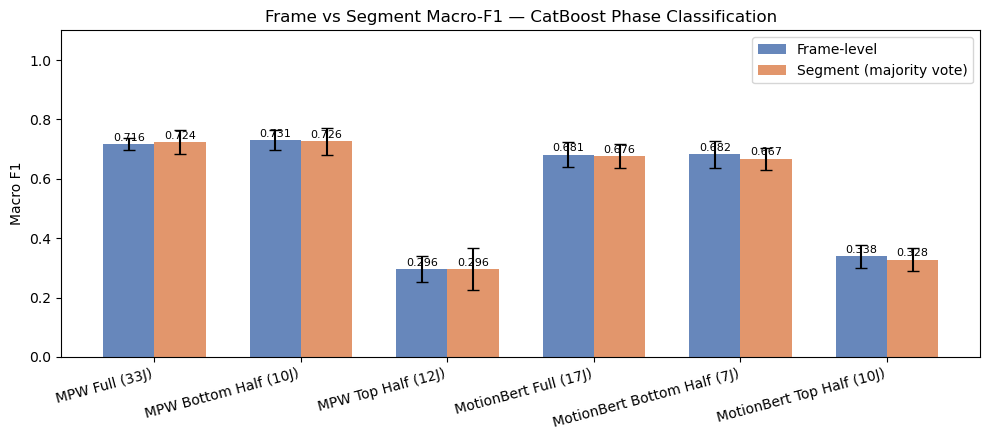

In [5]:
# ── Cross-experiment macro-F1 summary ─────────────────────────────────────────
summary_rows = []
for exp_name, fold_results in all_results.items():
    if not fold_results:
        continue
    frame_f1s = [r['frame_f1'] for r in fold_results]
    seg_f1s   = [r['seg_f1']   for r in fold_results]
    summary_rows.append({
        'Experiment':      exp_name,
        'Frame F1 Mean':   np.mean(frame_f1s),
        'Frame F1 Std':    np.std(frame_f1s),
        'Segment F1 Mean': np.mean(seg_f1s),
        'Segment F1 Std':  np.std(seg_f1s),
        'N Folds':         len(frame_f1s),
    })

df_summary = pd.DataFrame(summary_rows).set_index('Experiment')
print(df_summary.to_string(float_format=lambda x: f'{x:.4f}'))

fig, ax = plt.subplots(figsize=(10, 4.5))
x, w   = np.arange(len(df_summary)), 0.35
bars_f = ax.bar(x - w/2, df_summary['Frame F1 Mean'],   w,
                yerr=df_summary['Frame F1 Std'],   capsize=4,
                label='Frame-level', color='#4C72B0', alpha=0.85)
bars_s = ax.bar(x + w/2, df_summary['Segment F1 Mean'], w,
                yerr=df_summary['Segment F1 Std'], capsize=4,
                label='Segment (majority vote)', color='#DD8452', alpha=0.85)
for bar in [*bars_f, *bars_s]:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(df_summary.index, rotation=15, ha='right')
ax.set_ylabel('Macro F1')
ax.set_title('Frame vs Segment Macro-F1 — CatBoost Phase Classification')
ax.set_ylim(0, 1.1)
ax.legend()
plt.tight_layout()
plt.show()

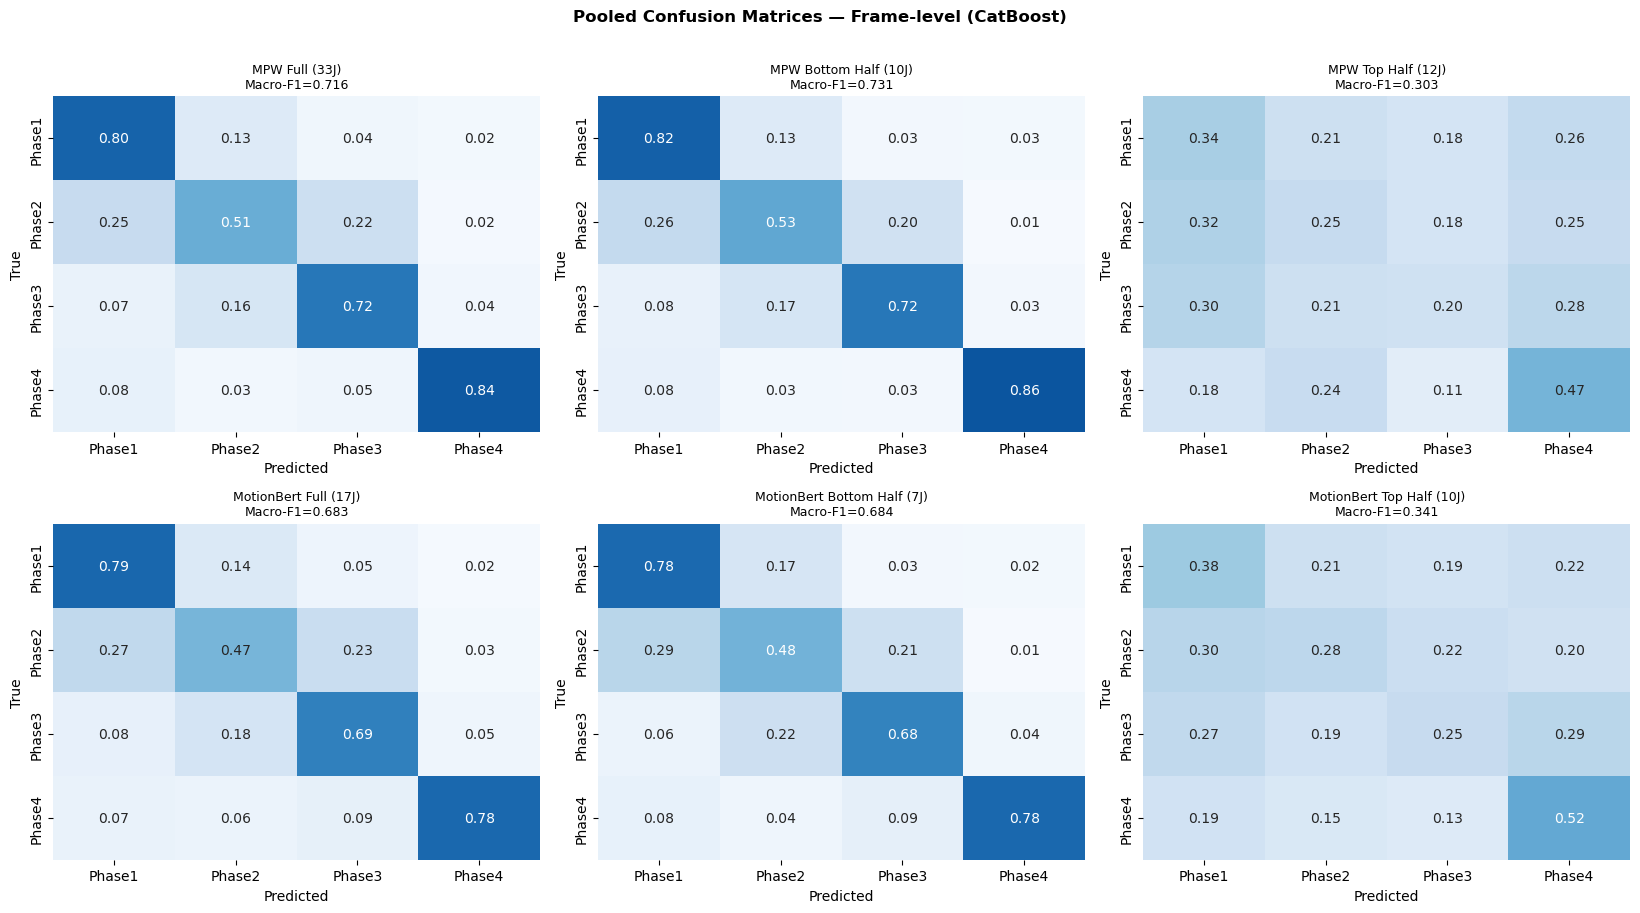

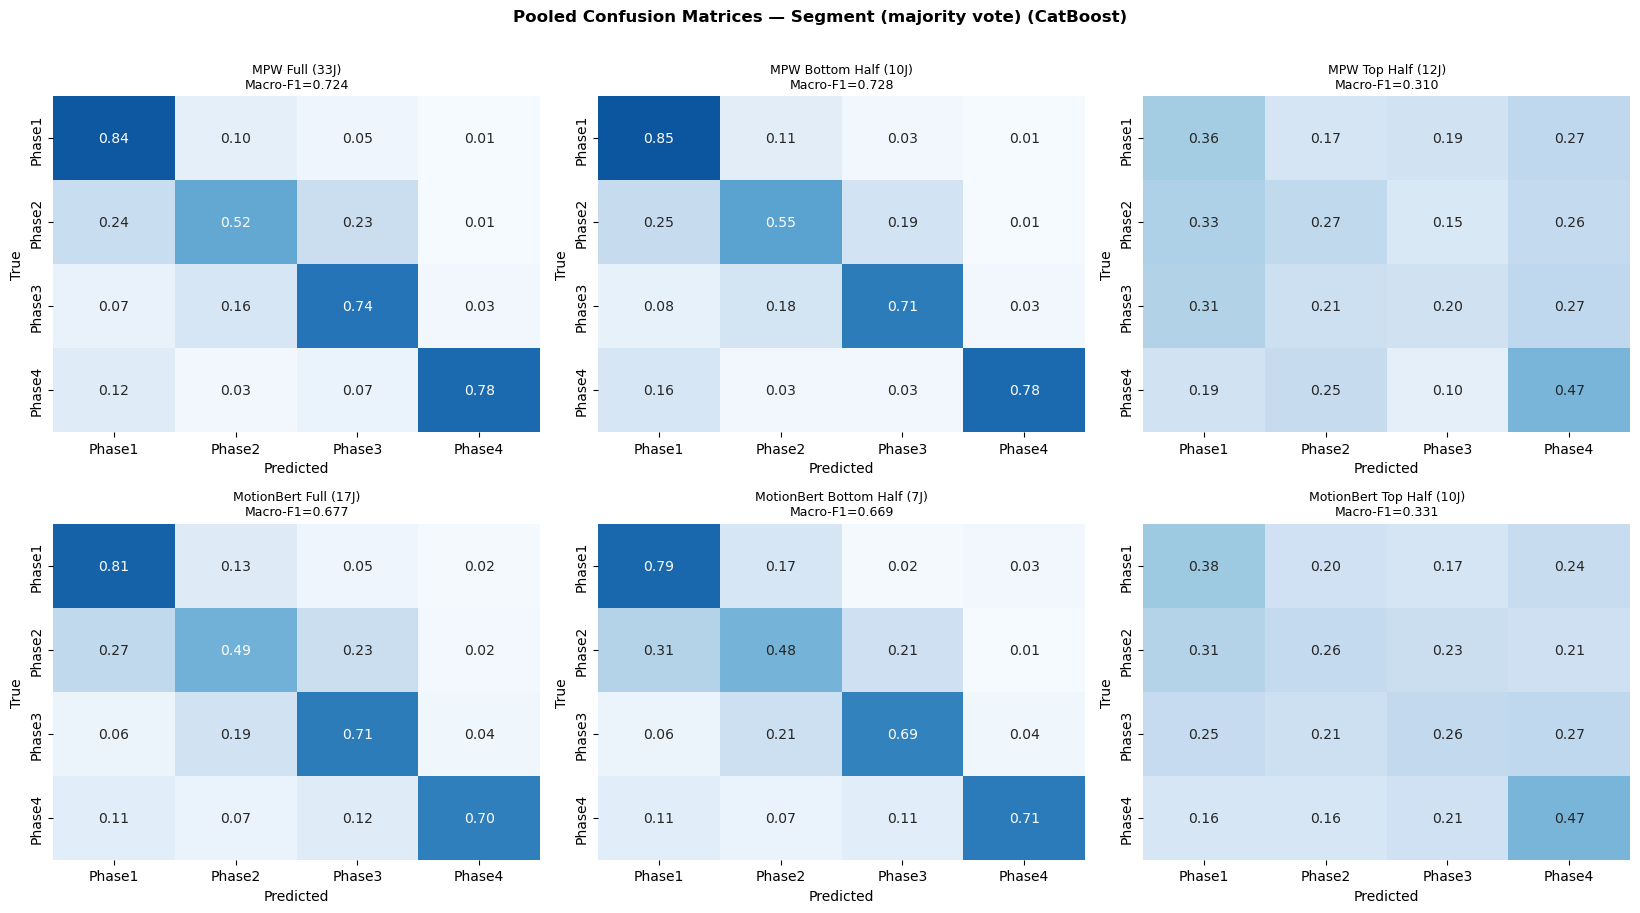

In [6]:
# ── Pooled confusion matrices ─────────────────────────────────────────────────
n_exp = len(all_results)
ncols = min(n_exp, 3)
nrows = (n_exp + ncols - 1) // ncols

for y_true_key, y_pred_key, title_suffix in [
    ('y_val',     'y_pred',    'Frame-level'),
    ('y_true_seg','y_pred_seg', 'Segment (majority vote)'),
]:
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4.5 * nrows))
    axes = np.array(axes).flatten()
    for ax, (exp_name, fold_results) in zip(axes, all_results.items()):
        if not fold_results:
            ax.set_visible(False)
            continue
        y_true_all = np.concatenate([r[y_true_key] for r in fold_results])
        y_pred_all = np.concatenate([r[y_pred_key] for r in fold_results])
        cm       = confusion_matrix(y_true_all, y_pred_all)
        cm_n     = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        macro_f1 = f1_score(y_true_all, y_pred_all, average='macro', zero_division=0)
        sns.heatmap(cm_n, annot=True, fmt='.2f', ax=ax,
                    xticklabels=PHASE_NAMES, yticklabels=PHASE_NAMES,
                    cmap='Blues', vmin=0, vmax=1, cbar=False)
        ax.set_title(f'{exp_name}\nMacro-F1={macro_f1:.3f}', fontsize=9)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')
    for ax in axes[n_exp:]:
        ax.set_visible(False)
    plt.suptitle(f'Pooled Confusion Matrices — {title_suffix} (CatBoost)', y=1.01, fontweight='bold')
    plt.tight_layout()
    plt.show()

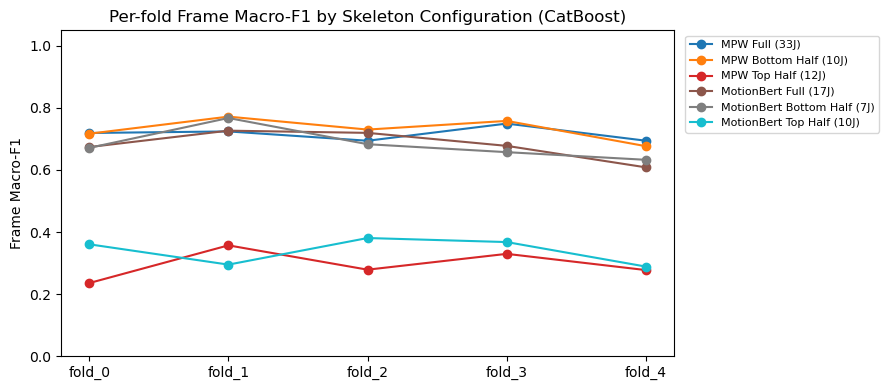

In [7]:
# ── Per-fold macro-F1 line plot ───────────────────────────────────────────────
fold_names = list(splits.keys())
fig, ax    = plt.subplots(figsize=(9, 4))
colors     = plt.cm.tab10(np.linspace(0, 0.9, len(all_results)))

for color, (exp_name, fold_results) in zip(colors, all_results.items()):
    if not fold_results:
        continue
    fold_f1s = {r['fold']: r['frame_f1'] for r in fold_results}
    ys = [fold_f1s.get(fn, np.nan) for fn in fold_names]
    ax.plot(fold_names, ys, marker='o', label=exp_name, color=color)

ax.set_ylabel('Frame Macro-F1')
ax.set_title('Per-fold Frame Macro-F1 by Skeleton Configuration (CatBoost)')
ax.set_ylim(0, 1.05)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()